<a href="https://colab.research.google.com/github/ShahidNauman/dataset-visualizer/blob/main/dataset-visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring and Visualizing the Iris Dataset

This notebook loads the Iris dataset, inspects its structure, and visualizes feature relationships and distributions using pandas, seaborn, and matplotlib.

## 1. Load the dataset using pandas.

In [26]:
import kagglehub
import pandas as pd

# Download the dataset via kagglehub
iris_path = kagglehub.dataset_download("uciml/iris")
print("Iris dataset path:", iris_path)

# Load the dataset using pandas
iris_df = pd.read_csv(iris_path + "/Iris.csv")

Using Colab cache for faster access to the 'iris' dataset.
Iris dataset path: /kaggle/input/iris


## 2. Print the shape, column names, and the first few rows of the dataset.

In [31]:
print("Shape:", iris_df.shape, end="\n\n")
print("Column names:", list(iris_df.columns), end="\n\n")
iris_df.head()

Shape: (150, 6)

Column names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Summary statistics.

In [38]:
# Info summary
iris_df.info()

# Descriptive statistics
iris_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


## 4. Visualize the dataset. Use matplotlib and seaborn for plotting.

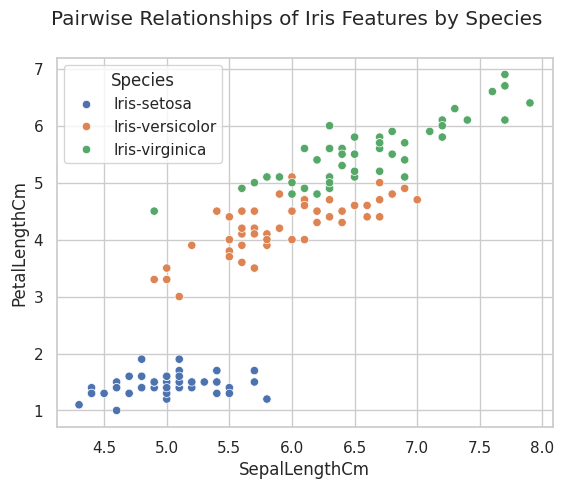

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to show relationships between features
plt.figure()
sns.scatterplot(data=iris_df, x='SepalLengthCm', y='PetalLengthCm', hue='Species')
plt.suptitle('Pairwise Relationships of Iris Features by Species')
plt.show()

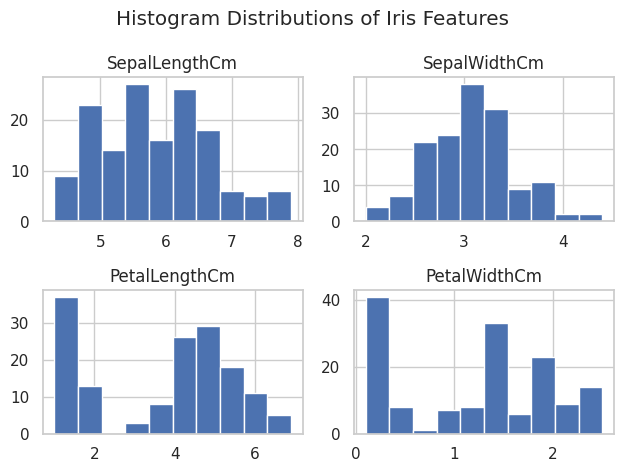

In [88]:
# Use histograms to show value distributions
numeric_columns = iris_df.select_dtypes(include='number').columns.drop('Id', errors='ignore')
iris_df[numeric_columns].hist()
plt.suptitle('Histogram Distributions of Iris Features')
plt.tight_layout()
plt.show()

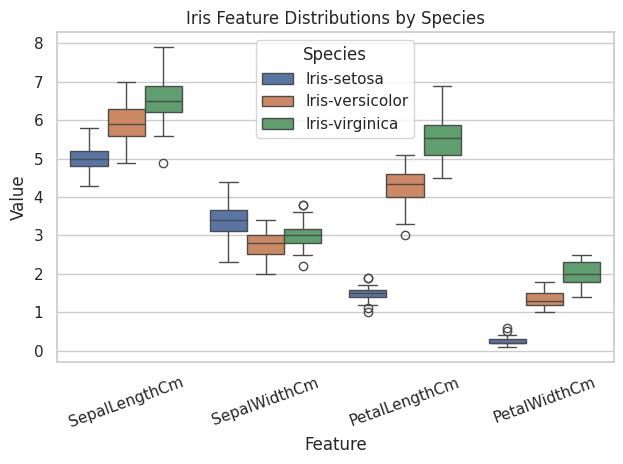

In [90]:
# Use box plots to identify outliers
melted = iris_df.melt(id_vars='Species', value_vars=numeric_columns)
plt.figure()
sns.boxplot(data=melted, x='variable', y='value', hue='Species')
plt.title('Iris Feature Distributions by Species')
plt.xlabel('Feature')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()